# 08 — Feature & Target Diagnosis

The previous notebook showed that more complex models only improved
performance modestly.

This suggests that model complexity may no longer be the main bottleneck.

In this notebook, we investigate:

- target balance
- feature separation
- feature redundancy
- target noise
- alternative prediction horizons and thresholds
- new market-regime features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/spy_modeling_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,return_1d,return_3d,return_5d,return_10d,return_20d,price_vs_sma5,price_vs_sma20,sma5_vs_sma20,volatility_5d,volatility_20d,volatility_ratio,high_low_range,overnight_gap,intraday_return,volume_ratio,target_3d
0,1993-03-01,-0.002814,0.000706,0.012866,-0.007008,0.007824,0.001980,-0.000212,-0.002187,0.006073,0.007807,0.777961,0.007763,0.003519,-0.006311,0.242519,1.0
1,1993-03-02,0.014820,0.013389,0.028612,0.033789,0.015536,0.011109,0.013818,0.002679,0.007720,0.008328,0.927048,0.015299,0.000706,0.014104,0.703432,0.0
2,1993-03-03,0.004173,0.016186,0.019774,0.038849,0.017618,0.011346,0.017152,0.005741,0.006591,0.008357,0.788662,0.004848,0.001391,0.002778,1.064048,1.0
3,1993-03-04,-0.005540,0.013408,0.011980,0.033837,0.001394,0.003354,0.011445,0.008065,0.007884,0.008151,0.967249,0.006964,0.001385,-0.006916,0.370992,1.0
4,1993-03-05,-0.002786,-0.004172,0.007741,0.027259,-0.005556,-0.000977,0.008912,0.009899,0.008232,0.008116,1.014345,0.009078,0.001393,-0.004172,0.184613,1.0


In [3]:
feature_cols = [
    col for col in df.columns
    if col not in ["Date","target_3d"]
]

In [4]:
target_counts = df["target_3d"].value_counts()
target_rates = df["target_3d"].value_counts(normalize=True)

print(f"Counts: {target_counts}\nRates: {target_rates}")

Counts: target_3d
0.0    4857
1.0    3571
Name: count, dtype: int64
Rates: target_3d
0.0    0.576293
1.0    0.423707
Name: proportion, dtype: float64


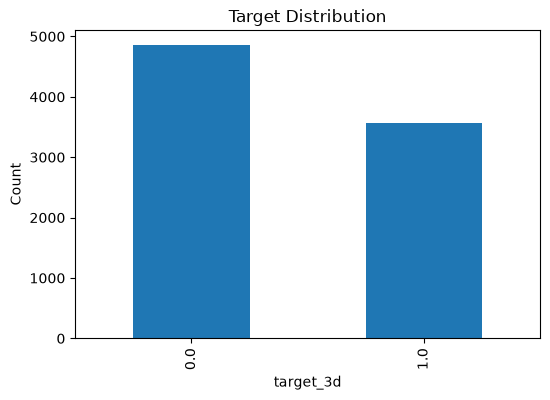

In [5]:
df["target_3d"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Target Distribution")
plt.xlabel("target_3d")
plt.ylabel("Count")
plt.show()

In [7]:
feature_means = df.groupby("target_3d")[feature_cols].mean().T

feature_means.columns = [
    "Target 0 Mean",
    "Target 1 Mean"
]

feature_means["Difference"] = (
    feature_means["Target 1 Mean"] - feature_means["Target 0 Mean"]
)

feature_means.sort_values("Difference",key=abs, ascending = False)

,Target 0 Mean,Target 1 Mean,Difference
volatility_ratio,0.941770,0.962008,0.020238
volume_ratio,1.007718,1.024980,0.017263
return_20d,0.011954,0.005486,-0.006468
return_10d,0.006620,0.001942,-0.004678
price_vs_sma20,0.005801,0.001648,-0.004153
return_5d,0.003962,0.000129,-0.003833
sma5_vs_sma20,0.004232,0.001659,-0.002573
return_3d,0.002394,0.000070,-0.002323
high_low_range,0.012111,0.013887,0.001776
price_vs_sma5,0.001519,-0.000081,-0.001600


In [8]:
# Made a mistake we should've standardize values before comparing

In [9]:
feature_std = df[feature_cols].std()

feature_means["Standardized Difference"] = (
    feature_means["Difference"] / feature_std
)

feature_means.sort_values(
    "Standardized Difference",
    key=abs,
    ascending=False
)

,Target 0 Mean,Target 1 Mean,Difference,Standardized Difference
high_low_range,0.012111,0.013887,0.001776,0.181857
price_vs_sma20,0.005801,0.001648,-0.004153,-0.166295
volatility_20d,0.009527,0.010569,0.001042,0.165845
return_5d,0.003962,0.000129,-0.003833,-0.161286
volatility_5d,0.008988,0.010093,0.001105,0.151488
return_10d,0.006620,0.001942,-0.004678,-0.146790
return_20d,0.011954,0.005486,-0.006468,-0.146196
price_vs_sma5,0.001519,-0.000081,-0.001600,-0.133585
sma5_vs_sma20,0.004232,0.001659,-0.002573,-0.132914
return_3d,0.002394,0.000070,-0.002323,-0.122562


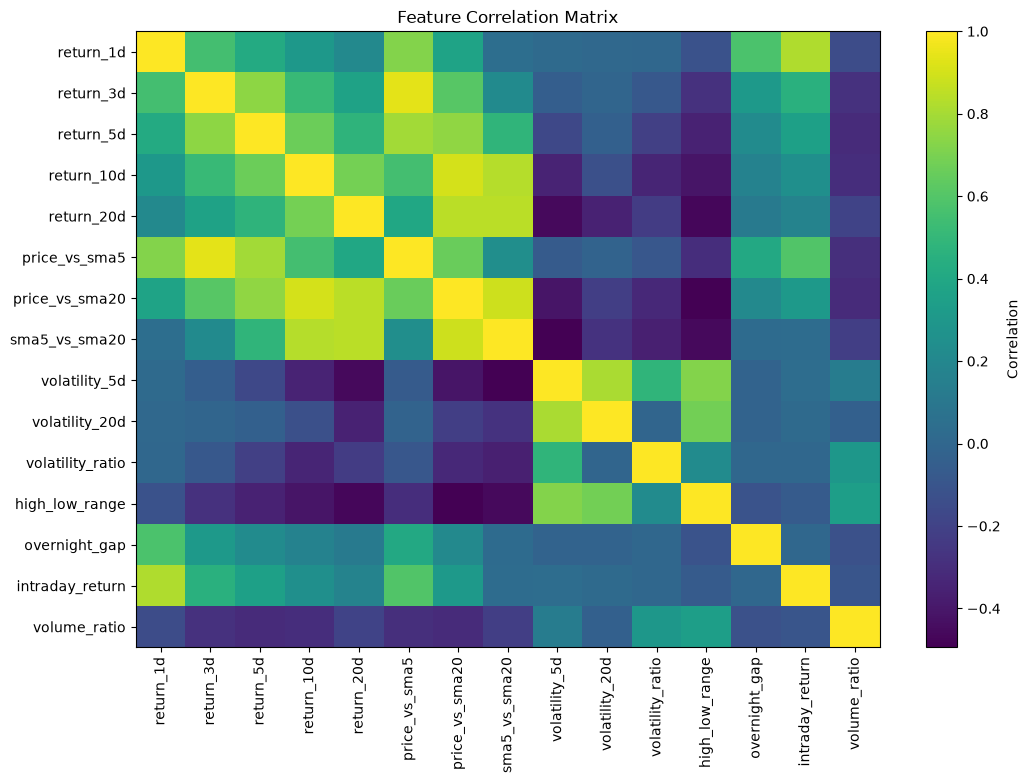

In [10]:
corr = df[feature_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")

plt.xticks(
    range(len(feature_cols)),
    feature_cols,
    rotation=90
)

plt.yticks(
    range(len(feature_cols)),
    feature_cols
)

plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
market = pd.read_csv("../data/spy_market_data.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.sort_values("Date").reset_index(drop=True)

market.head()

,Date,Adj Close,Close,High,Low,Open,Volume,return_1d,future_return_3d,target_3d
0,1993-01-29,24.113256,43.93750,43.96875,43.75000,43.96875,1003200,NaN,0.019915,1.0
1,1993-02-01,24.284769,44.25000,44.25000,43.96875,43.96875,480500,0.007113,0.016949,1.0
2,1993-02-02,24.336218,44.34375,44.37500,44.12500,44.21875,201300,0.002119,0.014094,1.0
3,1993-02-03,24.593472,44.81250,44.84375,44.37500,44.40625,529400,0.010571,0.003487,0.0
4,1993-02-04,24.696379,45.00000,45.09375,44.46875,44.96875,531500,0.004184,-0.007639,0.0


In [15]:
market["future_return_3d"] = (
    market["Adj Close"].shift(-3) / market["Adj Close"] - 1
)

market["future_return_5d"] = (
    market["Adj Close"].shift(-5) / market["Adj Close"] - 1
)

In [16]:
market["target_3d_0pct"] = (
    market["future_return_3d"] > 0.00
).astype(int)

market["target_3d_05pct"] = (
    market["future_return_3d"] > 0.005
).astype(int)

market["target_5d_05pct"] = (
    market["future_return_5d"] > 0.005
).astype(int)

market["target_5d_1pct"] = (
    market["future_return_5d"] > 0.01
).astype(int)

In [17]:
target_cols = [
    "target_3d_0pct",
    "target_3d_05pct",
    "target_5d_05pct",
    "target_5d_1pct"
]

for col in target_cols:
    print("\n", col)
    print(market[col].value_counts(normalize=True))


 target_3d_0pct
target_3d_0pct
1    0.578443
0    0.421557
Name: proportion, dtype: float64

 target_3d_05pct
target_3d_05pct
0    0.576195
1    0.423805
Name: proportion, dtype: float64

 target_5d_05pct
target_5d_05pct
0    0.527094
1    0.472906
Name: proportion, dtype: float64

 target_5d_1pct
target_5d_1pct
0    0.644699
1    0.355301
Name: proportion, dtype: float64


In [18]:
target_data = market[
    [
        "Date",
        "target_3d_0pct",
        "target_3d_05pct",
        "target_5d_05pct",
        "target_5d_1pct"
    ]
]

df_targets = df.merge(
    target_data,
    on="Date",
    how="inner"
)

df_targets.shape

(8428, 21)

In [19]:
X = df_targets[feature_cols]

In [20]:
split_idx = int(len(df_targets) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

target_cols = [
    "target_3d_0pct",
    "target_3d_05pct",
    "target_5d_05pct",
    "target_5d_1pct"
]

target_results = []

for target_col in target_cols:

    y = df_targets[target_col]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    test_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        test_proba
    )

    target_results.append({
        "Target": target_col,
        "Test AUC": auc,
        "Positive Rate": y.mean()
    })

In [25]:
target_results_df = pd.DataFrame(target_results)

target_results_df.sort_values(
    "Test AUC",
    ascending=False
)

,Target,Test AUC,Positive Rate
3,target_5d_1pct,0.578030,0.355244
1,target_3d_05pct,0.557949,0.423707
2,target_5d_05pct,0.546567,0.472829
0,target_3d_0pct,0.499648,0.578429


## Walk-Forward Target Comparison

The initial target experiment suggested that some target definitions may be more learnable than others.

However, comparing targets using only the final test period can be misleading.

We will now evaluate each target across multiple chronological validation folds using TimeSeriesSplit.

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [27]:
target_cols = [
    "target_3d_0pct",
    "target_3d_05pct",
    "target_5d_05pct",
    "target_5d_1pct"
]

In [28]:
target_cv_results = []

for target_col in target_cols:

    y = df_targets[target_col]

    X = df_targets[feature_cols]

    split_idx = int(len(df_targets) * 0.80)

    X_train = X.iloc[:split_idx]
    y_train = y.iloc[:split_idx]

    fold_scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_fold_train, y_fold_train)

        val_proba = model.predict_proba(X_fold_val)[:, 1]

        fold_auc = roc_auc_score(
            y_fold_val,
            val_proba
        )

        fold_scores.append(fold_auc)

    target_cv_results.append({
        "Target": target_col,
        "Mean Validation AUC": np.mean(fold_scores),
        "Std Validation AUC": np.std(fold_scores),
        "Fold Scores": fold_scores
    })

In [29]:
target_cv_df = pd.DataFrame(target_cv_results)

target_cv_df.sort_values(
    "Mean Validation AUC",
    ascending=False
)

,Target,Mean Validation AUC,Std Validation AUC,Fold Scores
3,target_5d_1pct,0.597254,0.033894,"[0.5866345896819032, 0.5662965951970684, 0.559..."
1,target_3d_05pct,0.568690,0.024371,"[0.5324905101975166, 0.5630558072418537, 0.557..."
2,target_5d_05pct,0.537790,0.024974,"[0.5623627859620096, 0.5040521790998327, 0.512..."
0,target_3d_0pct,0.512145,0.020322,"[0.5271603758560279, 0.4933903079188272, 0.538..."


In [31]:
target_name_map = {
    "target_3d_0pct": "3D > 0%",
    "target_3d_05pct": "3D > 0.5%",
    "target_5d_05pct": "5D > 0.5%",
    "target_5d_1pct": "5D > 1%"
}

clean_target_cv["Target"] = (
    clean_target_cv["Target"]
    .map(target_name_map)
)

clean_target_cv

,Target,Mean Validation AUC,Std Validation AUC
0,5D > 1%,0.5973,0.0339
1,3D > 0.5%,0.5687,0.0244
2,5D > 0.5%,0.5378,0.0250
3,3D > 0%,0.5121,0.0203
